<a href="https://colab.research.google.com/github/Trevorkaaya21/CIFAR-10-neural-networks-comparisons/blob/main/CIFAR10_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSC 485 Project 2 — CIFAR-10 Image Classification


In [33]:
#downloading the libaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

## Part 1: Setup and Data Exploration

### Load CIFAR-10 and display samples

In [32]:
#loading CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

Training shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


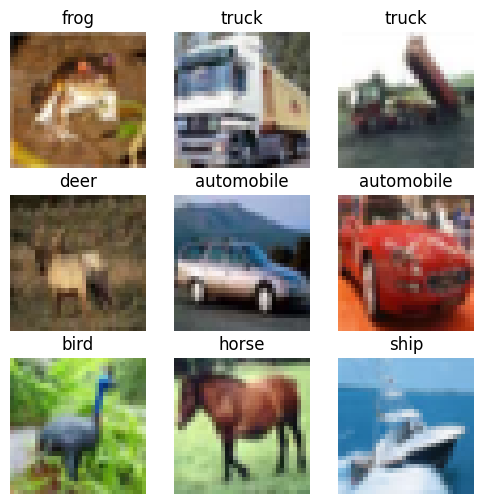

In [3]:
#displaying 9 sample images
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.show()

## Part 2: Preprocessing
Creating **training / validation / testing** subsets
Splitting the original training set into **45,000 train** and **5,000 validation**.

In [4]:
#normalize to [0, 1] and then create a validation split
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Create validation split
x_val = x_train[45000:]
y_val = y_train[45000:]

x_train = x_train[:45000]
y_train = y_train[:45000]

Function to Plot

In [5]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f'{title} Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'{title} Loss')
    plt.legend()

    plt.show()

## Part 3: Basic MLP (Baseline)

In [6]:
mlp = keras.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(10, activation='softmax')
])

mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mlp.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        30,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,730 (120.04 KB)

 Trainable params: 30,730 (120.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history_mlp = mlp.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3142 - loss: 1.9727 - val_accuracy: 0.3384 - val_loss: 1.8842
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3524 - loss: 1.8866 - val_accuracy: 0.3596 - val_loss: 1.8441
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3624 - loss: 1.8628 - val_accuracy: 0.3342 - val_loss: 1.9224
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3710 - loss: 1.8403 - val_accuracy: 0.3698 - val_loss: 1.8091
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3693 - loss: 1.8403 - val_accuracy: 0.3566 - val_loss: 1.8653
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3787 - loss: 1.8200 - val_accuracy: 0.3562 - val_loss: 1.8935
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3785 - loss: 1.8244 - val_accuracy: 0.3550 - val_loss: 1.8901
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3845 - loss: 1.8001 - 

Plotting he accuracy and loss

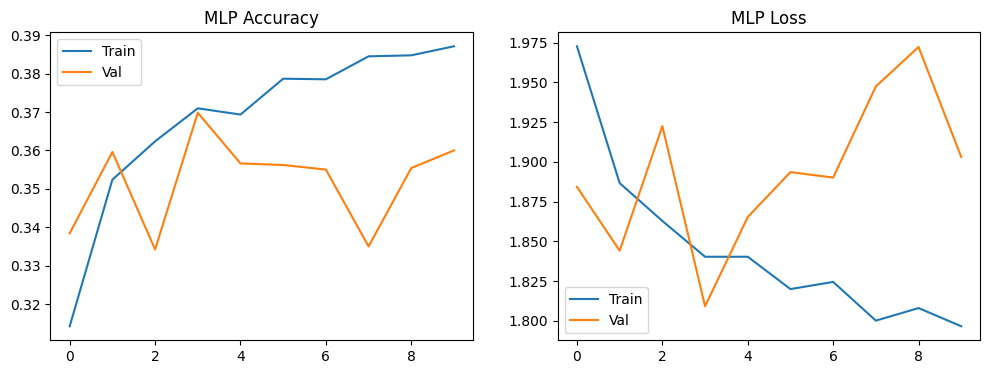

In [8]:
plot_history(history_mlp, "MLP")

Printing the test accuracy

In [9]:
mlp_test_acc = mlp.evaluate(x_test, y_test, verbose=0)[1]
print("MLP Test Accuracy:", mlp_test_acc)

MLP Test Accuracy: 0.3488999903202057


## Part 4: Regular ANN

In [10]:
ann = keras.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history_ann = ann.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3150 - loss: 1.9089 - val_accuracy: 0.3560 - val_loss: 1.8262
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3755 - loss: 1.7501 - val_accuracy: 0.3740 - val_loss: 1.7566
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3960 - loss: 1.7001 - val_accuracy: 0.3650 - val_loss: 1.7519
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4060 - loss: 1.6688 - val_accuracy: 0.4090 - val_loss: 1.6690
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4176 - loss: 1.6409 - val_accuracy: 0.4052 - val_loss: 1.6738
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4215 - loss: 1.6248 - val_accuracy: 0.4162 - val_loss: 1.6337
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4269 - loss: 1.6134 - val_accuracy: 0.4204 - val_loss: 1.6328
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4324 - loss: 1.5998 - 

Plotting the accuracy and loss for ANN

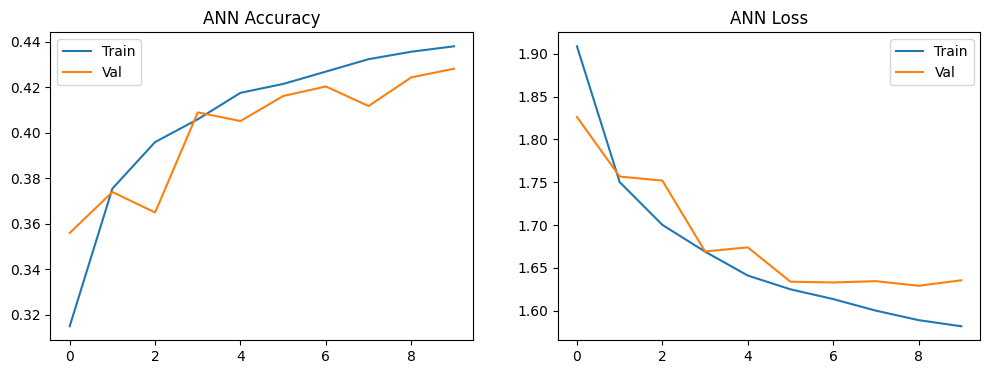

In [12]:
plot_history(history_ann, "ANN")

Printing the test accuracy

In [13]:
ann_test_acc = ann.evaluate(x_test, y_test, verbose=0)[1]
print("ANN Test Accuracy:", ann_test_acc)

ANN Test Accuracy: 0.42320001125335693


## Part 5: Deep Neural Network (DNN)

In [14]:
dnn = keras.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

dnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

dnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_dnn = dnn.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=32
)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.2008 - loss: 2.1015 - val_accuracy: 0.2816 - val_loss: 1.9328
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2470 - loss: 2.0020 - val_accuracy: 0.3026 - val_loss: 1.9202
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2566 - loss: 1.9822 - val_accuracy: 0.3160 - val_loss: 1.9134
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2704 - loss: 1.9591 - val_accuracy: 0.3114 - val_loss: 1.8919
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2777 - loss: 1.9426 - val_accuracy: 0.3228 - val_loss: 1.8955
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2854 - loss: 1.9297 - val_accuracy: 0.3098 - val_loss: 1.8952
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2879 - loss: 1.9228 - val_accuracy: 0.3178 - val_loss: 1.8968
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2876 - loss: 1.9232 -

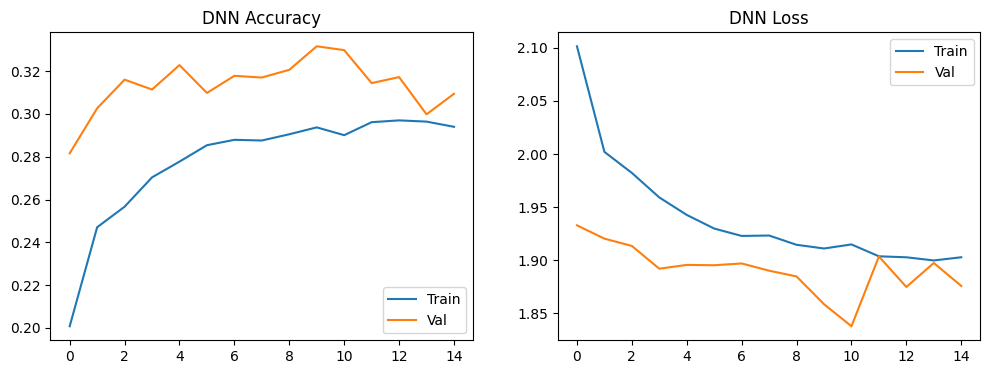

In [16]:
plot_history(history_dnn, "DNN")

In [17]:
dnn_test_acc = dnn.evaluate(x_test, y_test, verbose=0)[1]
print("DNN Test Accuracy:", dnn_test_acc)

DNN Test Accuracy: 0.3124000132083893


## Part 6: Convolutional Neural Network (CNN)


In [18]:
cnn = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_cnn = cnn.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=32
)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.4721 - loss: 1.4705 - val_accuracy: 0.5702 - val_loss: 1.2060
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6121 - loss: 1.1025 - val_accuracy: 0.6340 - val_loss: 1.0522
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6649 - loss: 0.9569 - val_accuracy: 0.6634 - val_loss: 0.9580
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6997 - loss: 0.8613 - val_accuracy: 0.6874 - val_loss: 0.9167
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7278 - loss: 0.7798 - val_accuracy: 0.6964 - val_loss: 0.8865
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7522 - loss: 0.7091 - val_accuracy: 0.6978 - val_loss: 0.8818
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7741 - loss: 0.6442 - val_accuracy: 0.7020 - val_loss: 0.8909
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7949 - loss: 0.5842 -

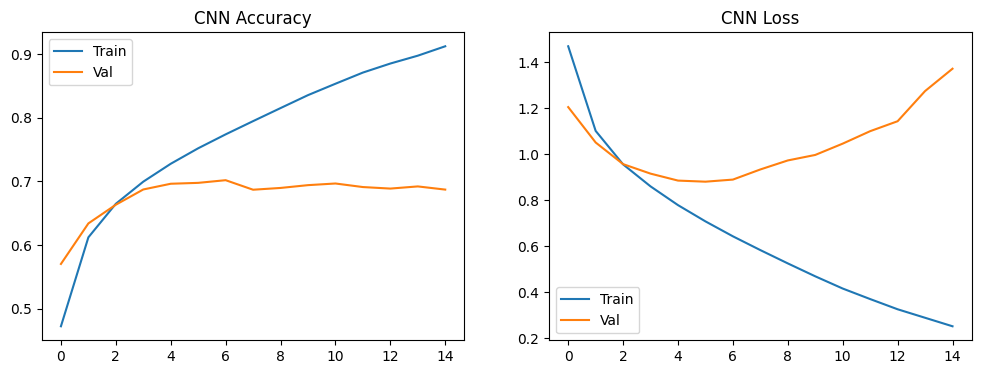

In [20]:
plot_history(history_cnn, "CNN")

In [21]:
cnn_test_acc = cnn.evaluate(x_test, y_test, verbose=0)[1]
print("CNN Test Accuracy:", cnn_test_acc)

CNN Test Accuracy: 0.6717000007629395


## Part 7: Pretrained Model (MobileNetV2)

In [22]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

Extra preprocessing for the pretrained model

In [23]:
x_train_resized = tf.image.resize(x_train, (96,96))
x_val_resized = tf.image.resize(x_val, (96,96))
x_test_resized = tf.image.resize(x_test, (96,96))

Phase 1- training the top layers

In [24]:
base_model = keras.applications.MobileNetV2(
    input_shape=(96,96,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [25]:
pretrained = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

pretrained.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
history_pre = pretrained.fit(
    x_train_resized, y_train,
    validation_data=(x_val_resized, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 45s 19ms/step - accuracy: 0.7498 - loss: 0.7171 - val_accuracy: 0.7802 - val_loss: 0.6124
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8034 - loss: 0.5590 - val_accuracy: 0.8052 - val_loss: 0.5671
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8233 - loss: 0.4980 - val_accuracy: 0.8054 - val_loss: 0.5801
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8411 - loss: 0.4476 - val_accuracy: 0.8060 - val_loss: 0.5517
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8555 - loss: 0.4052 - val_accuracy: 0.8062 - val_loss: 0.5671
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8708 - loss: 0.3651 - val_accuracy: 0.8114 - val_loss: 0.5750
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8846 - loss: 0.3273 - val_accuracy: 0.7988 - val_loss: 0.6198
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8943 - loss: 0.2979 

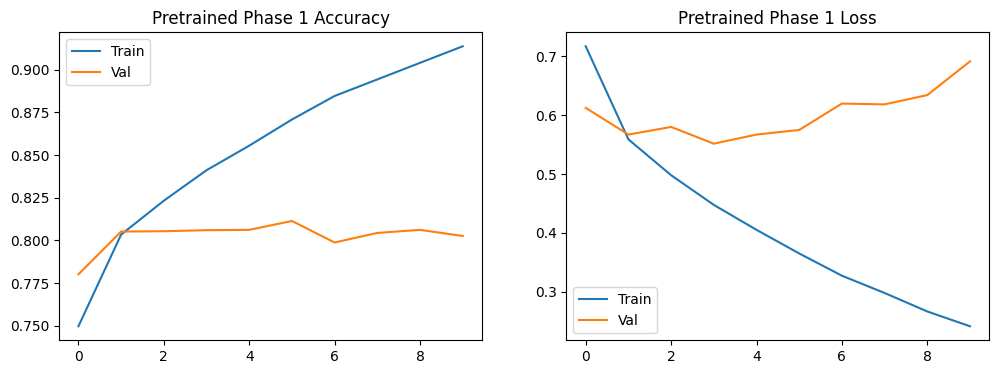

In [27]:
plot_history(history_pre, "Pretrained Phase 1")

Phase 2 - Fine Tuning

In [28]:
base_model.trainable = True

pretrained.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
history_fine = pretrained.fit(
    x_train_resized, y_train,
    validation_data=(x_val_resized, y_val),
    epochs=5,
    batch_size=32
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 97s 38ms/step - accuracy: 0.7270 - loss: 1.7583 - val_accuracy: 0.7800 - val_loss: 1.0669
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.8273 - loss: 0.8373 - val_accuracy: 0.8456 - val_loss: 0.7697
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.8549 - loss: 0.5973 - val_accuracy: 0.8658 - val_loss: 0.5879
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.8786 - loss: 0.4459 - val_accuracy: 0.8796 - val_loss: 0.5067
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.8989 - loss: 0.3348 - val_accuracy: 0.8858 - val_loss: 0.4688


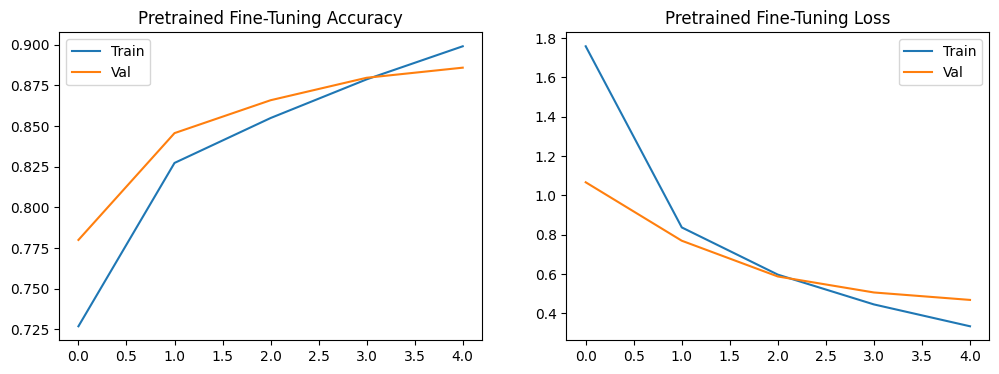

In [30]:
plot_history(history_fine, "Pretrained Fine-Tuning")

In [37]:
# Evaluate the final fine-tuned MobileNetV2 model on the test dataset
test_loss, test_accuracy = pretrained.evaluate(x_test_resized, y_test, verbose=1)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8763 - loss: 0.5198
Final Test Loss: 0.5198
Final Test Accuracy: 87.63%


In [39]:
import numpy as np
from sklearn.metrics import classification_report

#generate predictions
y_pred_probs = pretrained.predict(x_test_resized, verbose=1)

#convert prediction probabilities into class predictions
y_pred = np.argmax(y_pred_probs, axis=1)

#make sure true labels are one-dimensional
y_true = y_test.flatten()

#calculate precision, recall, and F1-score
report = classification_report(
    y_true,
    y_pred,
    output_dict=True
)

print(f"Precision: {report['weighted avg']['precision']:.4f}")
print(f"Recall:    {report['weighted avg']['recall']:.4f}")
print(f"F1 Score:  {report['weighted avg']['f1-score']:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step
Precision: 0.8765
Recall:    0.8763
F1 Score:  0.8760


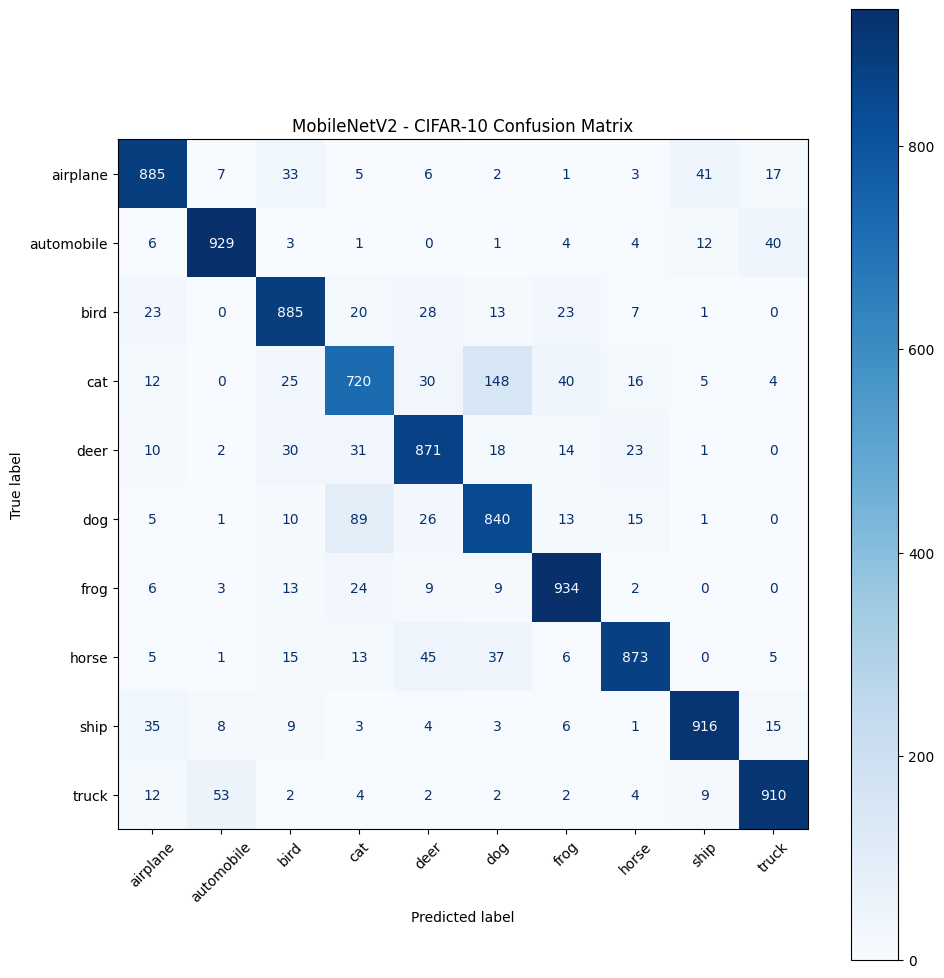

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(ax=ax, cmap="Blues", values_format="d")

plt.title("MobileNetV2 - CIFAR-10 Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
import time
import numpy as np

#warm up the model so startup overhead doesn't distort the measurement
_ = pretrained.predict(x_test_resized[:100], verbose=0)

#measure prediction time for 1,000 images
test_sample = x_test_resized[:1000]

start_time = time.perf_counter()

_ = pretrained.predict(test_sample, verbose=0)

end_time = time.perf_counter()

total_time = end_time - start_time
avg_latency_ms = (total_time / len(test_sample)) * 1000
throughput = len(test_sample) / total_time

print(f"Images tested: {len(test_sample):,}")
print(f"Total inference time: {total_time:.2f} seconds")
print(f"Average inference time: {avg_latency_ms:.2f} ms/image")
print(f"Throughput: {throughput:.2f} images/second")

Images tested: 1,000
Total inference time: 3.00 seconds
Average inference time: 3.00 ms/image
Throughput: 333.83 images/second


In [44]:
import os

#parameter counts
total_params = pretrained.count_params()
trainable_params = sum(
    int(p.shape.num_elements()) for p in pretrained.trainable_weights
)
non_trainable_params = total_params - trainable_params

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")

#save the final model
pretrained.save("cifar10_mobilenetv2.keras")

#measure saved model size
model_size_mb = os.path.getsize("cifar10_mobilenetv2.keras") / (1024 * 1024)

print(f"Saved model size: {model_size_mb:.2f} MB")

Total parameters: 2,423,242
Trainable parameters: 2,389,130
Non-trainable parameters: 34,112
Saved model size: 28.14 MB


In [45]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
import os
import shutil

save_folder = "/content/drive/MyDrive/CIFAR10_Project"
os.makedirs(save_folder, exist_ok=True)

shutil.copy(
    "cifar10_mobilenetv2.keras",
    f"{save_folder}/cifar10_mobilenetv2.keras"
)

print("Model saved permanently to Google Drive!")
print(f"Location: {save_folder}/cifar10_mobilenetv2.keras")

Running Tests on our model


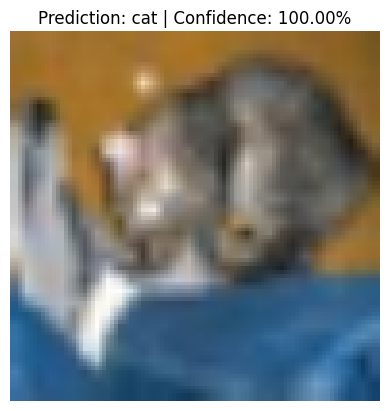

Predicted class: cat
Confidence: 100.00%


In [47]:
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Pick one image from the test set (using the resized version)
image = x_test_resized[0]

# Add batch dimension: (height, width, channels) -> (1, height, width, channels)
image_batch = np.expand_dims(image, axis=0)

# Make prediction
prediction = pretrained.predict(image_batch, verbose=0)

predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

# Display result
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Prediction: {predicted_class} | Confidence: {confidence:.2f}%"
)
plt.show()

print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

In [48]:
def predict_image(image):
    # Add batch dimension
    image_batch = np.expand_dims(image, axis=0)

    # Run model inference
    predictions = model.predict(image_batch, verbose=0)[0]

    # Get top 3 predictions
    top_3_indices = np.argsort(predictions)[-3:][::-1]

    top_predictions = []

    for index in top_3_indices:
        top_predictions.append({
            "class": class_names[index],
            "confidence": float(predictions[index])
        })

    return {
        "predicted_class": class_names[top_3_indices[0]],
        "confidence": float(predictions[top_3_indices[0]]),
        "top_3": top_predictions
    }

In [50]:
def predict_image(image):
    # Add batch dimension
    image_batch = np.expand_dims(image, axis=0)

    # Run model inference using the correct model variable 'pretrained'
    predictions = pretrained.predict(image_batch, verbose=0)[0]

    # Get top 3 predictions
    top_3_indices = np.argsort(predictions)[-3:][::-1]

    top_predictions = []

    for index in top_3_indices:
        top_predictions.append({
            "class": class_names[index],
            "confidence": float(predictions[index])
        })

    return {
        "predicted_class": class_names[top_3_indices[0]],
        "confidence": float(predictions[top_3_indices[0]]),
        "top_3": top_predictions
    }

# Call the updated predict_image function with the resized test image
result = predict_image(x_test_resized[0])

print("Prediction:", result["predicted_class"])
print(f"Confidence: {result['confidence'] * 100:.2f}%")

print("\nTop 3 Predictions:")

for prediction in result["top_3"]:
    print(
        f"{prediction['class']}: "
        f"{prediction['confidence'] * 100:.2f}%"
    )

Prediction: cat
Confidence: 100.00%

Top 3 Predictions:
cat: 100.00%
dog: 0.00%
frog: 0.00%


Saving premium_photo-1666777247416-ee7a95235559.avif to premium_photo-1666777247416-ee7a95235559.avif
Original image size: (3000, 4500)


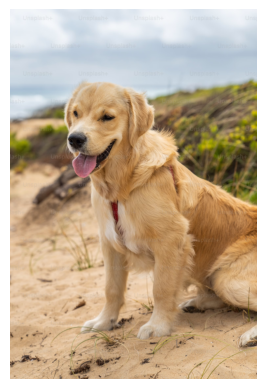

In [51]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()

# Get uploaded filename
filename = next(iter(uploaded))

# Open the image
uploaded_image = Image.open(filename).convert("RGB")

print("Original image size:", uploaded_image.size)

plt.imshow(uploaded_image)
plt.axis("off")
plt.show()

In [53]:
print("Model input shape:", pretrained.input_shape)

Model input shape: (None, 96, 96, 3)


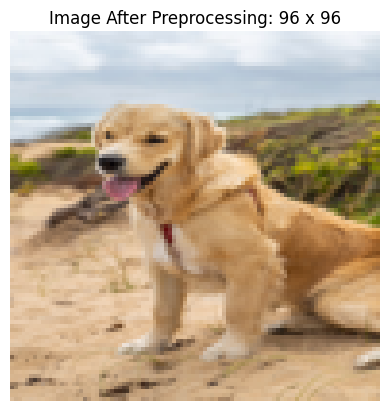

Processed image shape: (96, 96, 3)
Pixel range: 0.0 to 251.0


In [54]:
# Resize uploaded image to the size expected by the model
processed_image = uploaded_image.resize((96, 96))

# Convert image to NumPy array
processed_image_array = np.array(processed_image)

# Match the preprocessing used by the model
processed_image_array = processed_image_array.astype("float32")

# Display the resized image
plt.imshow(processed_image)
plt.axis("off")
plt.title("Image After Preprocessing: 96 x 96")
plt.show()

print("Processed image shape:", processed_image_array.shape)
print("Pixel range:", processed_image_array.min(), "to", processed_image_array.max())

In [56]:
for i, layer in enumerate(pretrained.layers[:10]):
    print(i, layer.name, type(layer).__name__)

0 mobilenetv2_1.00_96 Functional
1 global_average_pooling2d GlobalAveragePooling2D
2 dense_8 Dense
3 dense_9 Dense


In [58]:
base_model = pretrained.layers[0]

print("Base model:", base_model.name)
print("Input shape:", base_model.input_shape)

print("\nFirst 10 layers inside MobileNetV2:")
for i, layer in enumerate(base_model.layers[:10]):
    print(i, layer.name, type(layer).__name__)

Base model: mobilenetv2_1.00_96
Input shape: (None, 96, 96, 3)

First 10 layers inside MobileNetV2:
0 input_layer_4 InputLayer
1 Conv1 Conv2D
2 bn_Conv1 BatchNormalization
3 Conv1_relu ReLU
4 expanded_conv_depthwise DepthwiseConv2D
5 expanded_conv_depthwise_BN BatchNormalization
6 expanded_conv_depthwise_relu ReLU
7 expanded_conv_project Conv2D
8 expanded_conv_project_BN BatchNormalization
9 block_1_expand Conv2D


In [59]:
print("x_test shape:", x_test.shape)
print("x_test dtype:", x_test.dtype)
print("x_test minimum:", x_test.min())
print("x_test maximum:", x_test.max())

print("\nFirst image range:")
print("Min:", x_test[0].min())
print("Max:", x_test[0].max())

x_test shape: (10000, 32, 32, 3)
x_test dtype: uint8
x_test minimum: 0
x_test maximum: 255

First image range:
Min: 13
Max: 255


In [61]:
pretrained.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,201,504 (27.47 MB)

 Trainable params: 2,389,130 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

 Optimizer params: 4,778,262 (18.23 MB)

In [63]:
import inspect

print("Model input shape:", pretrained.input_shape)
print("Model output shape:", pretrained.output_shape)

# Check variables that may contain resized datasets
for name in [
    "x_train_resized",
    "x_test_resized",
    "x_val_resized",
    "X_train_resized",
    "X_test_resized",
    "X_val_resized"
]:
    if name in globals():
        data = globals()[name]
        print(
            name,
            "shape:", data.shape,
            "dtype:", data.dtype,
            "min:", tf.reduce_min(data),
            "max:", tf.reduce_max(data)
        )


Model input shape: (None, 96, 96, 3)
Model output shape: (None, 10)
x_train_resized shape: (45000, 96, 96, 3) dtype: <dtype: 'float32'> min: tf.Tensor(0.0, shape=(), dtype=float32) max: tf.Tensor(1.0, shape=(), dtype=float32)
x_test_resized shape: (10000, 96, 96, 3) dtype: <dtype: 'float32'> min: tf.Tensor(0.0, shape=(), dtype=float32) max: tf.Tensor(1.0, shape=(), dtype=float32)
x_val_resized shape: (5000, 96, 96, 3) dtype: <dtype: 'float32'> min: tf.Tensor(0.0, shape=(), dtype=float32) max: tf.Tensor(1.0, shape=(), dtype=float32)


Prediction: airplane
Confidence: 53.29%

Top 3 Predictions:
airplane: 53.29%
deer: 31.20%
horse: 11.87%


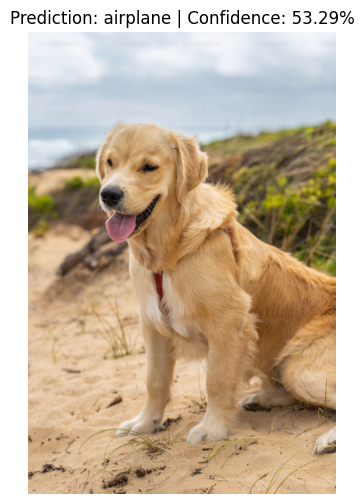

In [64]:
#resize the uploaded image to 96x96
real_image = uploaded_image.resize((96, 96))

#convert to NumPy array
real_image = np.array(real_image).astype("float32")

#normalize from 0-255 to 0-1
real_image = real_image / 255.0

#ddd batch dimension
real_image_batch = np.expand_dims(real_image, axis=0)

#make prediction using the trained MobileNetV2 model
predictions = pretrained.predict(real_image_batch, verbose=0)[0]

#get top 3 predictions
top_3_indices = np.argsort(predictions)[-3:][::-1]

print("Prediction:", class_names[top_3_indices[0]])
print(f"Confidence: {predictions[top_3_indices[0]] * 100:.2f}%")

print("\nTop 3 Predictions:")
for index in top_3_indices:
    print(f"{class_names[index]}: {predictions[index] * 100:.2f}%")

#display the original uploaded image
plt.figure(figsize=(6, 6))
plt.imshow(uploaded_image)
plt.axis("off")
plt.title(
    f"Prediction: {class_names[top_3_indices[0]]} | "
    f"Confidence: {predictions[top_3_indices[0]] * 100:.2f}%"
)
plt.show()

In [65]:
# Take one ORIGINAL CIFAR-10 test image
cifar_image = Image.fromarray(x_test[0])

# Process it exactly like an uploaded image
cifar_processed = cifar_image.resize((96, 96))
cifar_processed = np.array(cifar_processed).astype("float32") / 255.0
cifar_batch = np.expand_dims(cifar_processed, axis=0)

# Predict
predictions = pretrained.predict(cifar_batch, verbose=0)[0]

top_3_indices = np.argsort(predictions)[-3:][::-1]

# Actual CIFAR-10 label
actual_index = int(np.array(y_test[0]).squeeze())
actual_class = class_names[actual_index]

print("Actual class:", actual_class)
print("Predicted class:", class_names[top_3_indices[0]])
print(f"Confidence: {predictions[top_3_indices[0]] * 100:.2f}%")

print("\nTop 3 Predictions:")
for index in top_3_indices:
    print(f"{class_names[index]}: {predictions[index] * 100:.2f}%")

Actual class: cat
Predicted class: cat
Confidence: 97.83%

Top 3 Predictions:
cat: 97.83%
dog: 2.17%
frog: 0.00%


Prediction: horse
Confidence: 73.84%

Top 3 Predictions:
horse: 73.84%
deer: 11.65%
cat: 7.42%


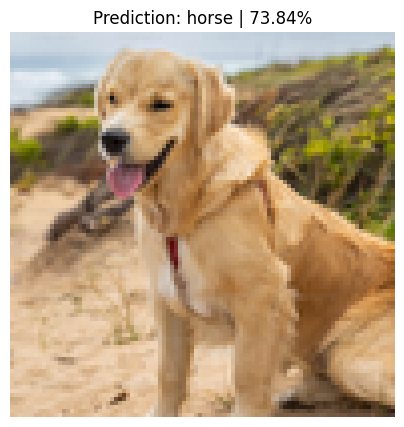

In [66]:
from PIL import ImageOps

# Center-crop the image to a square and resize to 96x96
real_image_cropped = ImageOps.fit(
    uploaded_image,
    (96, 96),
    method=Image.Resampling.LANCZOS,
    centering=(0.5, 0.5)
)

# Convert to array and normalize
real_image_array = np.array(real_image_cropped).astype("float32") / 255.0

# Add batch dimension
real_image_batch = np.expand_dims(real_image_array, axis=0)

# Predict
predictions = pretrained.predict(real_image_batch, verbose=0)[0]

top_3_indices = np.argsort(predictions)[-3:][::-1]

print("Prediction:", class_names[top_3_indices[0]])
print(f"Confidence: {predictions[top_3_indices[0]] * 100:.2f}%")

print("\nTop 3 Predictions:")
for index in top_3_indices:
    print(
        f"{class_names[index]}: "
        f"{predictions[index] * 100:.2f}%"
    )

# Show exactly what the model sees
plt.figure(figsize=(5, 5))
plt.imshow(real_image_cropped)
plt.axis("off")
plt.title(
    f"Prediction: {class_names[top_3_indices[0]]} | "
    f"{predictions[top_3_indices[0]] * 100:.2f}%"
)
plt.show()

In [67]:
def predict_uploaded_image(image):
    # Center crop and resize
    processed = ImageOps.fit(
        image.convert("RGB"),
        (96, 96),
        method=Image.Resampling.LANCZOS,
        centering=(0.5, 0.5)
    )

    # Convert and normalize
    array = np.array(processed).astype("float32") / 255.0

    # Add batch dimension
    batch = np.expand_dims(array, axis=0)

    # Run inference
    probabilities = pretrained.predict(batch, verbose=0)[0]

    # Top 3
    top_indices = np.argsort(probabilities)[-3:][::-1]

    return {
        "predicted_class": class_names[top_indices[0]],
        "confidence": float(probabilities[top_indices[0]]),
        "top_3": [
            {
                "class": class_names[i],
                "confidence": float(probabilities[i])
            }
            for i in top_indices
        ]
    }

In [68]:
result = predict_uploaded_image(uploaded_image)

print("Prediction:", result["predicted_class"])
print(f"Confidence: {result['confidence'] * 100:.2f}%")

print("\nTop 3:")
for item in result["top_3"]:
    print(f"{item['class']}: {item['confidence'] * 100:.2f}%")

Prediction: horse
Confidence: 73.84%

Top 3:
horse: 73.84%
deer: 11.65%
cat: 7.42%


In [69]:
from google.colab import files
from PIL import Image
import io

uploaded_test_images = files.upload()

print(f"\nUploaded {len(uploaded_test_images)} images")

Saving classic-vintage-car.jpg to classic-vintage-car.jpg
Saving gray-tabby-cat.jpg to gray-tabby-cat.jpg
Saving horse-3-768x501.jpg to horse-3-768x501.jpg
Saving images.jpeg to images.jpeg
Saving premium_photo-1666777247416-ee7a95235559.avif to premium_photo-1666777247416-ee7a95235559 (1).avif

Uploaded 5 images


In [71]:
expected_labels = {
    "classic-vintage-car.jpg": "automobile",
    "gray-tabby-cat.jpg": "cat",
    "horse-3-768x501.jpg": "horse",
    "images.jpeg": "airplane",
    "premium_photo-1666777247416-ee7a95235559 (1).avif": "dog"
}

results = []

for filename, file_data in uploaded_test_images.items():

    image = Image.open(io.BytesIO(file_data)).convert("RGB")
    result = predict_uploaded_image(image)

    expected = expected_labels[filename]
    correct = result["predicted_class"] == expected

    results.append({
        "Filename": filename,
        "Expected": expected,
        "Predicted": result["predicted_class"],
        "Confidence": f"{result['confidence'] * 100:.2f}%",
        "Correct": correct
    })

results_df = pd.DataFrame(results)

display(results_df)

correct_count = results_df["Correct"].sum()
total_count = len(results_df)

print(f"\nExploratory real-world test: {correct_count}/{total_count} correctly classified")

,Filename,Expected,Predicted,Confidence,Correct
0,classic-vintage-car.jpg,automobile,automobile,82.66%,True
1,gray-tabby-cat.jpg,cat,cat,87.45%,True
2,horse-3-768x501.jpg,horse,cat,95.96%,False
3,images.jpeg,airplane,airplane,100.00%,True
4,premium_photo-1666777247416-ee7a95235559 (1).avif,dog,horse,73.84%,False



Exploratory real-world test: 3/5 correctly classified


In [ ]:
# Saving as a PDF

def colab2pdf():
  ENABLE=True # @param {type:"boolean"}
  if ENABLE:
    !apt-get install librsvg2-bin
    import os, datetime, json, locale, pathlib, urllib, requests, werkzeug, nbformat, google, yaml, warnings
    locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')
    NAME = pathlib.Path(werkzeug.utils.secure_filename(urllib.parse.unquote(requests.get(f"http://{os.environ['COLAB_JUPYTER_IP']}:{os.environ['KMP_TARGET_PORT']}/api/sessions").json()[0]["name"])))
    TEMP = pathlib.Path("/content/pdfs") / f"{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}_{NAME.stem}"; TEMP.mkdir(parents=True, exist_ok=True)
    NB = [cell for cell in nbformat.reads(json.dumps(google.colab._message.blocking_request("get_ipynb", timeout_sec=600)["ipynb"]), as_version=4).cells if "--Colab2PDF" not in cell.source]
    warnings.filterwarnings('ignore', category=nbformat.validator.MissingIDFieldWarning)
    with (TEMP / f"{NAME.stem}.ipynb").open("w", encoding="utf-8") as nb_copy: nbformat.write(nbformat.v4.new_notebook(cells=NB or [nbformat.v4.new_code_cell("#")]), nb_copy)
    if not pathlib.Path("/usr/local/bin/quarto").exists():
      !wget -q "https://quarto.org/download/latest/quarto-linux-amd64.deb" -P {TEMP} && dpkg -i {TEMP}/quarto-linux-amd64.deb > /dev/null && quarto install tinytex --update-path --quiet
      with (TEMP / "config.yml").open("w", encoding="utf-8") as file: yaml.dump({'include-in-header': [{"text": r"\usepackage{fvextra}\DefineVerbatimEnvironment{Highlighting}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines,breakanywhere,commandchars=\\\{\}}"}],'include-before-body': [{"text": r"\DefineVerbatimEnvironment{verbatim}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines}"}]}, file)
      !quarto render {TEMP}/{NAME.stem}.ipynb --metadata-file={TEMP}/config.yml --to pdf -M latex-auto-install -M margin-top=1in -M margin-bottom=1in -M margin-left=1in -M margin-right=1in --quiet
      google.colab.files.download(str(TEMP / f"{NAME.stem}.pdf"))
colab2pdf()